### Simple Hierarchical Multi-Agent System with Groq
Shows how to organize agents in teams with team leaders.

Structure:
- CEO (top level)
    - Research Team Leader
        - Data Researcher
        - Market Researcher
    - Writing Team Leader
        - Technical Writer
        - Summary Writer

In [1]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
import random
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000189C6E010D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000189C7F354D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:
# ===================================
# Shared State and CEO
# ===================================

class HierarchicalState(MessagesState):
    """State shared by the CEO and both team subgraphs."""
    current_task: str = ""
    data_research: str = ""
    market_research: str = ""
    technical_draft: str = ""
    summary_draft: str = ""
    final_report: str = ""
    next_node: str = ""


def ceo_agent(state: HierarchicalState) -> Dict:
    """The CEO delegates to one team at a time and reviews the final work."""
    task = state.get("current_task") or next(
        (message.content for message in state["messages"] if isinstance(message, HumanMessage)),
        "No task provided"
    )
    
    if state.get("final_report"):
        message = "✅ CEO: Both teams are complete. Final report approved."
        next_node = "end"
    elif not state.get("data_research") or not state.get("market_research"):
        message = "🏢 CEO: Assigning the task to the Research Team Leader..."
        next_node = "research_team"
    else:
        message = "🏢 CEO: Research is complete. Assigning the task to the Writing Team Leader..."
        next_node = "writing_team"
    
    return {
        "messages": [AIMessage(content=message)],
        "current_task": task,
        "next_node": next_node
    }


# ===================================
# Research Team Leader
# ===================================

def research_leader(state: HierarchicalState) -> Dict:
    """The Research Team Leader chooses the next research specialist."""
    if not state.get("data_research"):
        next_node = "data_researcher"
        message = "🔬 Research Team Leader: Assigning facts and statistics to Data Researcher..."
    elif not state.get("market_research"):
        next_node = "market_researcher"
        message = "🔬 Research Team Leader: Assigning trends and examples to Market Researcher..."
    else:
        next_node = "team_done"
        message = "🔬 Research Team Leader: Research specialists have completed their assignments."
    
    return {
        "messages": [AIMessage(content=message)],
        "next_node": next_node
    }


In [10]:
# ===================================
# Research Specialists
# ===================================

def data_researcher(state: HierarchicalState) -> Dict:
    """Data Researcher reports its result back to its team leader."""
    task = state["current_task"]
    prompt = f"""You are the Data Researcher in a hierarchical team.
Research facts, background, evidence, and useful statistics for:
{task}
Be concise and identify important benefits, risks, and examples."""
    result = llm.invoke([HumanMessage(content=prompt)]).content
    message = f"📚 Data Researcher: Assignment complete.\n\n{result[:700]}..."
    return {
        "messages": [AIMessage(content=message)],
        "data_research": result,
        "next_node": "research_leader"
    }


def market_researcher(state: HierarchicalState) -> Dict:
    """Market Researcher reports its result back to its team leader."""
    task = state["current_task"]
    prompt = f"""You are the Market Researcher in a hierarchical team.
Research current trends, adoption, stakeholders, and real-world examples for:
{task}
Explain opportunities and challenges organizations should consider."""
    result = llm.invoke([HumanMessage(content=prompt)]).content
    message = f"📈 Market Researcher: Assignment complete.\n\n{result[:700]}..."
    return {
        "messages": [AIMessage(content=message)],
        "market_research": result,
        "next_node": "research_leader"
    }


In [11]:
# ===================================
# Writing Team Leader
# ===================================

def writing_leader(state: HierarchicalState) -> Dict:
    """The Writing Team Leader chooses the next writing specialist."""
    if not state.get("technical_draft"):
        next_node = "technical_writer"
        message = "✍️ Writing Team Leader: Assigning the detailed draft to Technical Writer..."
    elif not state.get("final_report"):
        next_node = "summary_writer"
        message = "✍️ Writing Team Leader: Assigning the executive summary to Summary Writer..."
    else:
        next_node = "team_done"
        message = "✍️ Writing Team Leader: Writing specialists have completed their assignments."
    
    return {
        "messages": [AIMessage(content=message)],
        "next_node": next_node
    }


# ===================================
# Writing Specialists
# ===================================

def technical_writer(state: HierarchicalState) -> Dict:
    """Technical Writer reports its draft back to its team leader."""
    prompt = f"""You are the Technical Writer.
Create a clear technical draft for: {state['current_task']}

Data research:
{state.get('data_research', '')[:1200]}

Market research:
{state.get('market_research', '')[:1200]}

Include key findings, benefits, risks, and recommendations."""
    result = llm.invoke([HumanMessage(content=prompt)]).content
    message = f"📝 Technical Writer: Assignment complete.\n\n{result[:700]}..."
    return {
        "messages": [AIMessage(content=message)],
        "technical_draft": result,
        "next_node": "writing_leader"
    }


def summary_writer(state: HierarchicalState) -> Dict:
    """Summary Writer returns the completed report to its team leader."""
    prompt = f"""You are the Summary Writer.
Create a concise executive report for: {state['current_task']}

Technical draft:
{state.get('technical_draft', '')[:1400]}

Research notes:
{state.get('data_research', '')[:700]}
{state.get('market_research', '')[:700]}

Use sections: Executive Summary, Key Findings, Risks and Opportunities,
Recommendations, and Conclusion."""
    result = llm.invoke([HumanMessage(content=prompt)]).content
    final_report = f"""FINAL REPORT
{'=' * 60}
Topic: {state['current_task']}
{'=' * 60}

{result}
"""
    message = "📄 Summary Writer: Assignment complete. Report sent to Writing Team Leader."
    return {
        "messages": [AIMessage(content=message)],
        "final_report": final_report,
        "next_node": "writing_leader"
    }


In [ ]:
# ===================================
# Build Two Team Subgraphs
# ===================================

# Research Team: the leader owns and routes its specialists.
research_workflow = StateGraph(HierarchicalState)
research_workflow.add_node("research_leader", research_leader)
research_workflow.add_node("data_researcher", data_researcher)
research_workflow.add_node("market_researcher", market_researcher)
research_workflow.set_entry_point("research_leader")
research_workflow.add_edge("data_researcher", "research_leader")
research_workflow.add_edge("market_researcher", "research_leader")
research_workflow.add_conditional_edges(
    "research_leader",
    lambda state: state["next_node"],
    {
        "data_researcher": "data_researcher",
        "market_researcher": "market_researcher",
        "team_done": END
    }
)
research_team = research_workflow.compile()


# Writing Team: the leader owns and routes its specialists.
writing_workflow = StateGraph(HierarchicalState)
writing_workflow.add_node("writing_leader", writing_leader)
writing_workflow.add_node("technical_writer", technical_writer)
writing_workflow.add_node("summary_writer", summary_writer)
writing_workflow.set_entry_point("writing_leader")
writing_workflow.add_edge("technical_writer", "writing_leader")
writing_workflow.add_edge("summary_writer", "writing_leader")
writing_workflow.add_conditional_edges(
    "writing_leader",
    lambda state: state["next_node"],
    {
        "technical_writer": "technical_writer",
        "summary_writer": "summary_writer",
        "team_done": END
    }
)
writing_team = writing_workflow.compile()


# ===================================
# Build the CEO Graph
# ===================================

workflow = StateGraph(HierarchicalState)
workflow.add_node("ceo", ceo_agent)
workflow.add_node("research_team", research_team)
workflow.add_node("writing_team", writing_team)
workflow.set_entry_point("ceo")
workflow.add_edge("research_team", "ceo")
workflow.add_edge("writing_team", "ceo")
workflow.add_conditional_edges(
    "ceo",
    lambda state: state["next_node"],
    {
        "research_team": "research_team",
        "writing_team": "writing_team",
        "end": END
    }
)

graph = workflow.compile()
print("CEO controls: research_team -> writing_team -> CEO")
print("Research Team Leader controls: data_researcher, market_researcher")
print("Writing Team Leader controls: technical_writer, summary_writer")


CEO controls: research_team -> writing_team -> CEO
Research Team Leader controls: data_researcher, market_researcher
Writing Team Leader controls: technical_writer, summary_writer


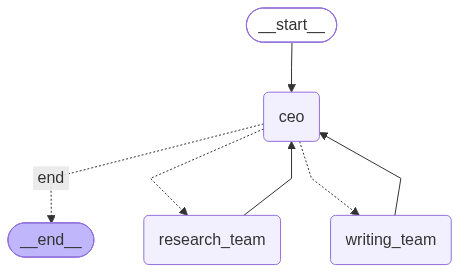

In [17]:
graph

In [15]:
# ===================================
# Run the Complete Hierarchical Workflow
# ===================================

task = "What are the benefits and risks of AI in healthcare?"
response = {}
printed_message_ids = set()

for update in graph.stream({"messages": [HumanMessage(content=task)]}):
    for node_update in update.values():
        response.update(node_update)
        for message in node_update.get("messages", []):
            # Child graphs can replay the accumulated message list.
            if isinstance(message, AIMessage) and message.id not in printed_message_ids:
                print(message.content)
                printed_message_ids.add(message.id)

print("\n" + response["final_report"])


🏢 CEO: Assigning the task to the Research Team Leader...
🔬 Research Team Leader: Assigning facts and statistics to Data Researcher...
📚 Data Researcher: Assignment complete.

**AI in Healthcare – Key Benefits, Risks, and Illustrative Examples**

| Category | Highlights | Evidence / Statistics |
|----------|------------|------------------------|
| **Benefits** | • **Improved Diagnostic Accuracy** – AI‑assisted radiology can detect lung nodules with 90 % sensitivity vs 80 % for radiologists alone. <br>• **Early Disease Detection** – Predictive models identify diabetic retinopathy 1–2 years earlier than standard screening. <br>• **Personalized Treatment** – Genomic AI platforms (e.g., Tempus) match patients to targeted therapies with a 15 % higher response rate. <br>• **Operational Efficiency** – AI triage chatbots reduce ED wait times by 30 % and cut administrative...
🔬 Research Team Leader: Assigning trends and examples to Market Researcher...
📈 Market Researcher: Assignment complete.



In [18]:
# ===================================
# Multiple Questions Example
# ===================================

questions = [
    "What are the benefits and risks of AI in healthcare?",
    "How can small businesses adopt renewable energy?",
    "What are the opportunities and challenges of remote work?"
]


def run_hierarchical_question(question: str) -> Dict:
    """Run one question through the CEO and both team subgraphs."""
    print(f"\nQUESTION: {question}")
    result = {}
    printed_message_ids = set()
    
    for update in graph.stream({"messages": [HumanMessage(content=question)]}):
        for node_update in update.values():
            result.update(node_update)
            for message in node_update.get("messages", []):
                if isinstance(message, AIMessage) and message.id not in printed_message_ids:
                    print(message.content.split("\n\n")[0])
                    printed_message_ids.add(message.id)
    
    return result


print("Available questions:")
for number, question in enumerate(questions, start=1):
    print(f"{number}. {question}")

# Run one question at a time to observe the complete hierarchy.
selected_question = questions[0]
question_response = run_hierarchical_question(selected_question)


Available questions:
1. What are the benefits and risks of AI in healthcare?
2. How can small businesses adopt renewable energy?
3. What are the opportunities and challenges of remote work?

QUESTION: What are the benefits and risks of AI in healthcare?
🏢 CEO: Assigning the task to the Research Team Leader...
🔬 Research Team Leader: Assigning facts and statistics to Data Researcher...
📚 Data Researcher: Assignment complete.
🔬 Research Team Leader: Assigning trends and examples to Market Researcher...
📈 Market Researcher: Assignment complete.
🔬 Research Team Leader: Research specialists have completed their assignments.
🏢 CEO: Research is complete. Assigning the task to the Writing Team Leader...
✍️ Writing Team Leader: Assigning the detailed draft to Technical Writer...
📝 Technical Writer: Assignment complete.
✍️ Writing Team Leader: Assigning the executive summary to Summary Writer...
📄 Summary Writer: Assignment complete. Report sent to Writing Team Leader.
✍️ Writing Team Leader: Wr